In [13]:
import os
import ast
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [14]:
CSV_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\src\filtered_padchest_14_diseases.csv"

IMAGES_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive\images-224\images-224"

SAVE_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\processed_dataset"

os.makedirs(SAVE_PATH, exist_ok=True)


In [15]:
df = pd.read_csv(CSV_PATH)

print("Dataset Shape :", df.shape)

display(df.head())


Dataset Shape : (107116, 37)


,Index,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS,FilteredLabels
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[],['normal']
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378'],['pulmonary fibrosis']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378'],['pulmonary fibrosis']
3,5,313903302629300007485735352869488750471_75sg0k...,0,20170125,313903302629300007485735352869488750471,3707275269754751392247446521222810702,1978.0,M,NaN,AP,...,1192.00,5310833,objet mejori radiolog con practic resolucion ...,Physician,"['unchanged', 'alveolar pattern', 'interstitia...","['loc basal', 'loc left']","[['unchanged'], ['alveolar pattern', 'intersti...",['C1332240' 'C2073538'],['C1282378' 'C0443246'],"['alveolar pattern', 'interstitial pattern']"
4,6,3137231742710829928-247610802266403640553_km0q...,0,20150804,3137231742710829928-247610802266403640553,93535126770783451980359712286922420997,1957.0,M,NaN,L,...,261.00,4969767,radiografi actual comp con previ 26 juni pers...,Physician,"['laminar atelectasis', 'pleural effusion', 'a...","['loc basal', 'loc subsegmental', 'loc pleural...","[['laminar atelectasis', 'loc subsegmental', '...",['C2073625' 'C4305366' 'C0185792'],['C1282378' 'C0929165' 'C0032225' 'C0444532' '...,['pleural effusion']


In [16]:
df_single = df[
    df['FilteredLabels'].apply(
        lambda x: len(ast.literal_eval(x)) == 1
    )
].copy()

print("Single Label Dataset Shape :", df_single.shape)

Single Label Dataset Shape : (92737, 37)


In [17]:
df_single['Label'] = df_single['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

display(df_single[['ImageID', 'Label']].head())

,ImageID,Label
0,20536686640136348236148679891455886468_k6ga29.png,normal
1,135803415504923515076821959678074435083_fzis7d...,pulmonary fibrosis
2,135803415504923515076821959678074435083_fzis7b...,pulmonary fibrosis
4,3137231742710829928-247610802266403640553_km0q...,pleural effusion
5,3137231742710829928-247610802266403640553_kine...,pleural effusion


In [18]:
class_counts = df_single['Label'].value_counts()

print(class_counts)

Label
normal                   50501
copd signs               17916
cardiomegaly              9271
pleural effusion          4511
interstitial pattern      2589
nodule                    2169
alveolar pattern          1864
atelectasis               1014
hilar enlargement          725
tuberculosis sequelae      631
pulmonary fibrosis         485
rib fracture               475
pneumothorax               351
mediastinal mass           235
Name: count, dtype: int64


In [19]:
label_encoder = LabelEncoder()

df_single['EncodedLabel'] = label_encoder.fit_transform(
    df_single['Label']
)

# Save class mapping
mapping_df = pd.DataFrame({
    'ClassName': label_encoder.classes_,
    'EncodedLabel': range(len(label_encoder.classes_))
})

display(mapping_df)

mapping_df.to_csv(
    os.path.join(SAVE_PATH, "label_mapping.csv"),
    index=False
)


,ClassName,EncodedLabel
0,alveolar pattern,0
1,atelectasis,1
2,cardiomegaly,2
3,copd signs,3
4,hilar enlargement,4
5,interstitial pattern,5
6,mediastinal mass,6
7,nodule,7
8,normal,8
9,pleural effusion,9


In [20]:
df_single['ImagePath'] = df_single['ImageID'].apply(
    lambda x: os.path.join(IMAGES_PATH, x)
)

display(df_single[['ImageID', 'ImagePath']].head())

,ImageID,ImagePath
0,20536686640136348236148679891455886468_k6ga29.png,C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\f...
1,135803415504923515076821959678074435083_fzis7d...,C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\f...
2,135803415504923515076821959678074435083_fzis7b...,C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\f...
4,3137231742710829928-247610802266403640553_km0q...,C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\f...
5,3137231742710829928-247610802266403640553_kine...,C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\f...


In [21]:
import pandas as pd

CSV_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\src\filtered_padchest_14_diseases.csv"

df_single = pd.read_csv(CSV_PATH)

print(df_single.shape)

(107116, 37)


In [22]:
import os
from tqdm import tqdm

BASE_DIR = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive\images-224\images-224"

# Build full image paths
df_single['ImagePath'] = df_single['ImageID'].apply(
    lambda x: os.path.join(BASE_DIR, str(x))
)

# Check missing images
missing_images = []

for path in tqdm(df_single['ImagePath']):

    if not os.path.exists(path):

        missing_images.append(path)

print("\nMissing Images :", len(missing_images))

# Keep only existing images
df_single = df_single[
    ~df_single['ImagePath'].isin(missing_images)
]

print("Final Dataset Shape :", df_single.shape)

100%|██████████| 107116/107116 [00:06<00:00, 16320.77it/s]



Missing Images : 10
Final Dataset Shape : (107106, 38)


In [24]:
patients = df_single['PatientID'].unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.15,
    random_state=42
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.15,
    random_state=42
)

# Create splits
train_df = df_single[
    df_single['PatientID'].isin(train_patients)
]

val_df = df_single[
    df_single['PatientID'].isin(val_patients)
]

test_df = df_single[
    df_single['PatientID'].isin(test_patients)
]

In [25]:
print("="*50)

print("TRAIN SET :", train_df.shape)

print("VALIDATION SET :", val_df.shape)

print("TEST SET :", test_df.shape)

print("="*50)


TRAIN SET : (77450, 38)
VALIDATION SET : (13648, 38)
TEST SET : (16008, 38)


In [26]:
train_patients_set = set(train_df['PatientID'])
val_patients_set = set(val_df['PatientID'])
test_patients_set = set(test_df['PatientID'])

print("Train-Val Overlap :",
      len(train_patients_set & val_patients_set))

print("Train-Test Overlap :",
      len(train_patients_set & test_patients_set))

print("Val-Test Overlap :",
      len(val_patients_set & test_patients_set))

Train-Val Overlap : 0
Train-Test Overlap : 0
Val-Test Overlap : 0


In [27]:
train_df.to_csv(
    os.path.join(SAVE_PATH, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SAVE_PATH, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SAVE_PATH, "test.csv"),
    index=False
)

print("\nDataset splits saved successfully")


Dataset splits saved successfully


In [28]:
IMG_SIZE = 224

def preprocess_image(image_path):

    # Read image
    img = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Resize
    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    # Normalize
    img = img / 255.0

    return img


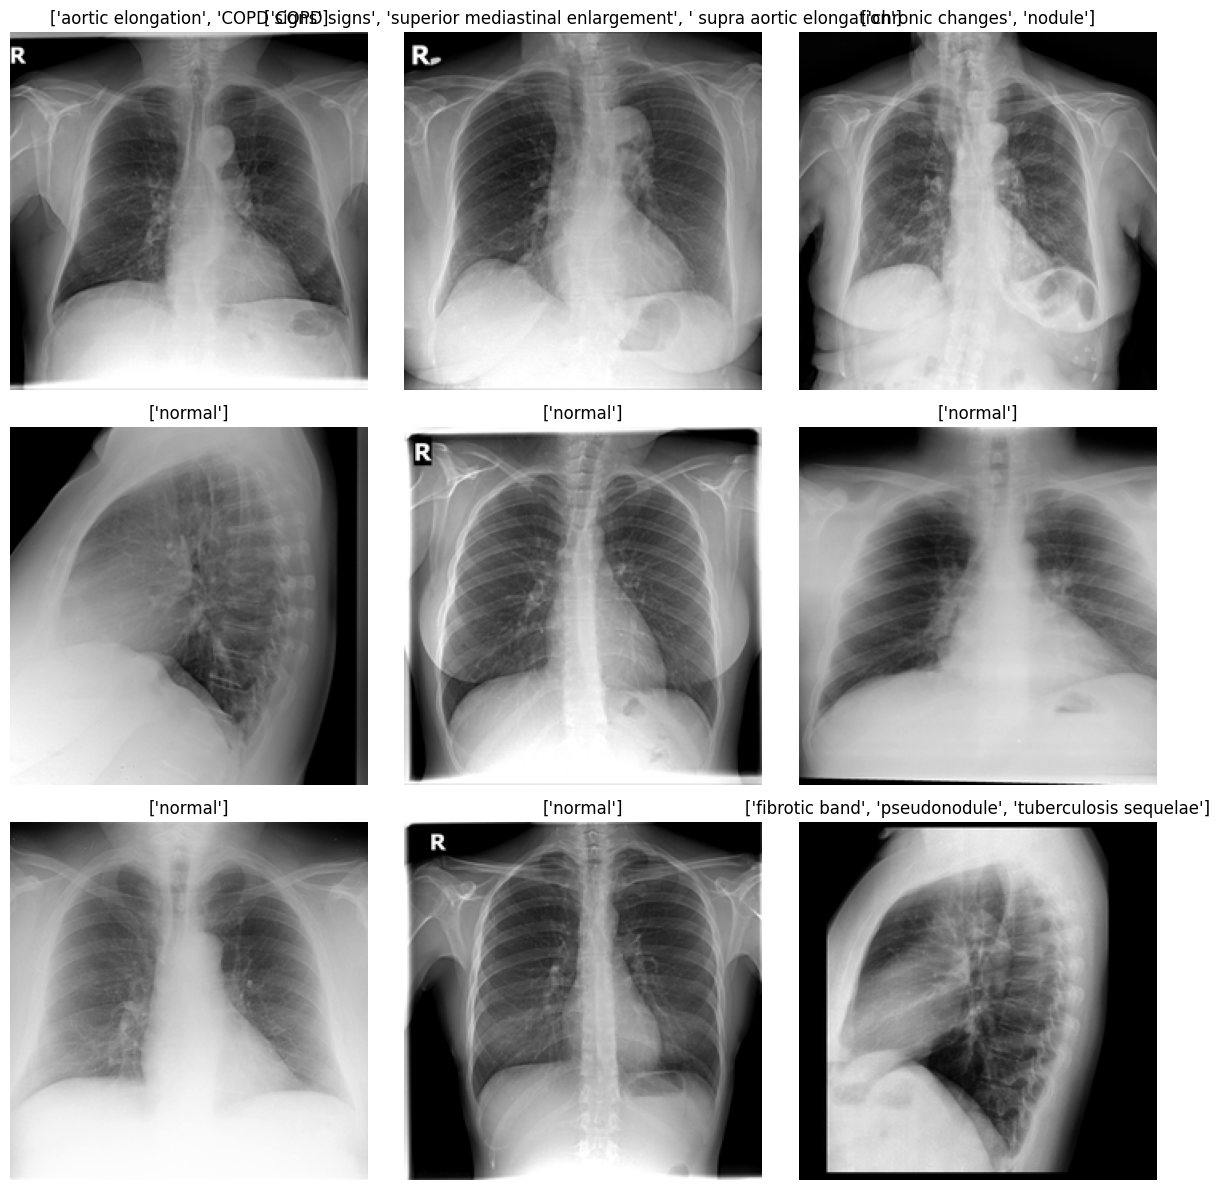

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive\images-224\images-224"

df_single['ImagePath'] = df_single['ImageID'].apply(
    lambda x: os.path.join(BASE_DIR, str(x))
)

sample_df = df_single.sample(9)

fig, axes = plt.subplots(3,3, figsize=(12,12))

for ax, (_, row) in zip(axes.flatten(),
                        sample_df.iterrows()):

    try:

        img = preprocess_image(row['ImagePath'])

        ax.imshow(img, cmap='gray')

        ax.set_title(row['Labels'])

        ax.axis('off')

    except Exception as e:

        print(e)

        ax.axis('off')

plt.tight_layout()

plt.show()

In [30]:
def apply_clahe(image):

    image_uint8 = (image * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(image_uint8)

    enhanced = enhanced / 255.0

    return enhanced

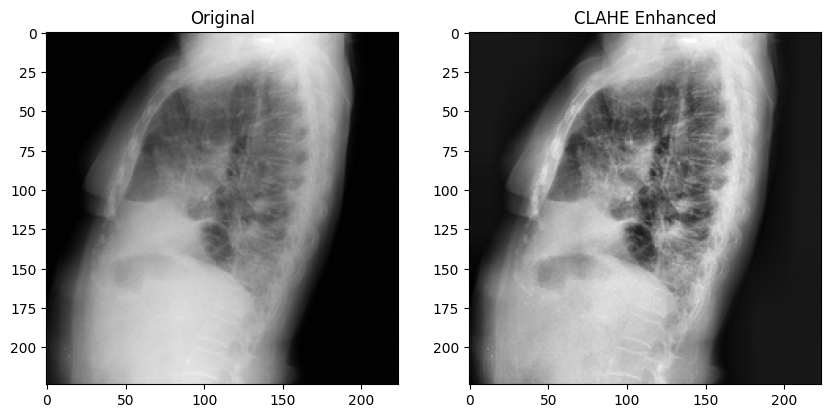

In [31]:
sample_image_path = random.choice(
    train_df['ImagePath'].values
)

original = preprocess_image(sample_image_path)

enhanced = apply_clahe(original)

fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title("CLAHE Enhanced")

plt.show()


In [32]:
final_df = pd.concat([
    train_df.assign(Split='train'),
    val_df.assign(Split='val'),
    test_df.assign(Split='test')
])

final_df.to_csv(
    os.path.join(SAVE_PATH, "final_dataset.csv"),
    index=False
)

print("\nFinal dataset saved successfully")


Final dataset saved successfully


In [35]:
valid_classes = label_encoder.classes_
print("\n" + "="*60)
print("PREPROCESSING COMPLETED")
print("="*60)

print(f"""
Final Number of Classes : {len(valid_classes)}

Training Images         : {len(train_df)}

Validation Images       : {len(val_df)}

Testing Images          : {len(test_df)}

Image Size              : {IMG_SIZE} x {IMG_SIZE}

Dataset Ready For Deep Learning
""")


PREPROCESSING COMPLETED

Final Number of Classes : 14

Training Images         : 77450

Validation Images       : 13648

Testing Images          : 16008

Image Size              : 224 x 224

Dataset Ready For Deep Learning



dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'IMG_SIZE', 'preprocess_image', '_i2', '_i3', '_i4', '_i5', '_i6', 'pd', 'CSV_PATH', '_i7', 'df_single', '_i8', 'os', 'BASE_DIR', '_i9', 'sample_df', '_i10', 'ast', 'cv2', 'random', 'warnings', 'np', 'plt', 'tqdm', 'train_test_split', 'LabelEncoder', '_i11', 'IMAGES_PATH', 'SAVE_PATH', '_i12', '_i13', '_i14', '_i15', 'df', '_i16', '_i17', '_i18', 'class_counts', '_i19', 'label_encoder', 'mapping_df', '_i20', '_i21', '_i22', 'missing_images', 'path', '_i23', 'patients', 'train_patients', 'test_patients', 'val_patients', 'train_df', 'val_df', 'test_df', '_i24', '_i25', '_i26', 'train_patients_set', 'val_patients_set', 'test_patients_set', '_i27', '_i28', '_i29', 'fig', 'axes', 'ax', 'row', 'img', '_i30', 'apply_clahe', '_i31', 'sample_image_path